# Relational Database Management Systems 

**SQL** (Structured Query Language) is a database computer language designed for managing structured data in **R**elational **D**ata**B**ase **M**anagement **S**ystems (RDBMS).

There are different types (extensions) of SQL RDBMSs:

* [**SQLite**](https://www.sqlite.org/index.html) is a C-language library that implements a small, fast, self-contained, high-reliability, full-featured, SQL database engine. It is the most used database engine in  the world. SQLite is free and open-source.

* [**MySQL**](https://www.mysql.com/why-mysql/) is a free and open-source RDBMS written in C and C++. Many of the world's largest and fastest-growing organizations including GitHub, US Navy, NASA, Tesla, Netflix, WeChat, Facebook, Zendesk, Twitter, Zappos, YouTube, Spotify and [others](https://www.mysql.com/customers/) rely on MySQL to save time and money powering their high-volume Web sites, business-critical systems and packaged software.

* [**PostgreSQL**](https://www.postgresql.org/) is an object-relational database management system (ORDBMS). It is also a free software. As with many other open-source programs, PostgreSQL is not controlled by any single company, but has a global community of developers and companies to develop it. It is considered as the world's most advanced open source relational database system. Here are some well-known companies using PostgreSQL: Apple, BioPharm, Etsy, IMDB, Macworld, Debian, Fujitsu, Red Hat, Sun Microsystem, Cisco, Skype. See the full list [here](https://stackshare.io/postgresql).


You can read more about the differences between these systems, for example [here](https://logz.io/blog/relational-database-comparison/).

The aim of this lab is to show how one can use Python to interact with SQL databases. If you want to learn more about SQL syntax, here is a useful [link](https://www.w3schools.com/sql/default.asp) with examples. 

# Database Schema

We will create a small relational database `soldiers_info` and use it throughout this lab as an example. The database will consist of four tables:

1. Soldiers

2. Ranks

3. Weapons

4. Units

The Entity-Relationship (ER) diagram of the database schema is shown below:

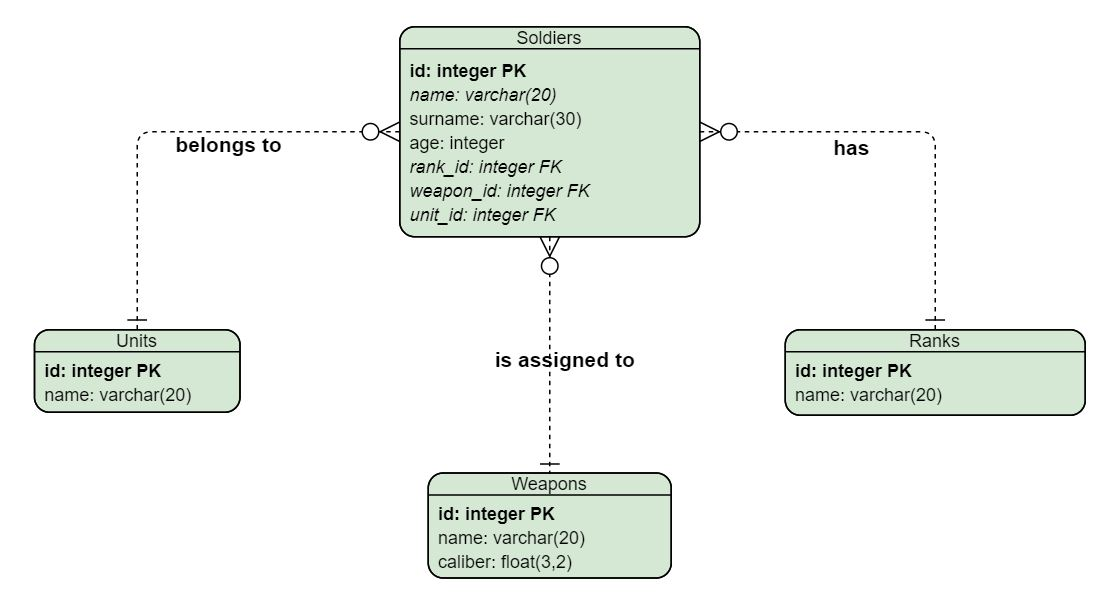

In [ ]:
from IPython.display import Image
Image("ER_diagram.JPG", width=850)

# SQLite with Python

SQLite is probably the most straightforward database to connect to with a Python application, since it doesn't require to install any external Python SQL modules. By default, your Python installation contains a Python SQL library named `sqlite3` that you can use to interact with an SQLite database.

SQLite databases are **serverless** and **self-contained**, since they read and write data to a file with **.db** extension. 

Now, let's write a helper function to connect to an SQLite database.

In [ ]:
import sqlite3
from sqlite3 import Error

def create_connection(path):
  """ 
  Takes the path to the SQLite DB
  and a connection is established with it in case the DB exists
  at the specified location. Otherwise, a new DB is created 
  at the specified location, and a connection is established.
  """
  connection = None    
  try:
      connection = sqlite3.connect(path)
      print("Successfully connected to the SQLite DB!")
  except Error as e:
      print(f"The following error occurred while connecting\
      to the SQLite DB:\n{e}")

  return connection

In [ ]:
print(create_connection.__doc__)

 
  Takes the path to the SQLite DB
  and a connection is established with it in case the DB exists
  at the specified location. Otherwise, a new DB is created 
  at the specified location, and a connection is established.
  


Let's create the database file in the current directory. Note that the file needs to be with an **.db** or **.sqlite** extension.

In [ ]:
connection = create_connection("soldiers_info.db")

Successfully connected to the SQLite DB!


## Create Tables

Now that the DB file is initialized, lets create the tables within it. 
We will need another helper function to execute queries in SQLite.


In [ ]:
def execute_query(connection, query):
  """
  Takes the connection object and the query string,
  which is passed to the query executor.
  """
  cursor = connection.cursor()
  try:
      cursor.execute(query)
      connection.commit()
      print("The query was executed successfully")
  except Error as e:
      print(f"The following error occurred:\n{e}")

Now let's write the queries that will create the tables (`soldiers, ranks, weapons, units`) within our database. You can [learn more](https://www.w3schools.com/sql/sql_constraints.asp) about SQL constrains, used to specify rules for the data in a table.

In [ ]:
create_ranks_table = """
CREATE TABLE IF NOT EXISTS ranks (
  id INTEGER PRIMARY KEY AUTOINCREMENT,
  name VARCHAR(20) NOT NULL
);
"""

create_weapons_table = """
CREATE TABLE IF NOT EXISTS weapons (
  id INTEGER PRIMARY KEY AUTOINCREMENT,
  name VARCHAR(20) NOT NULL,
  caliber FLOAT(3,2) NOT NULL
);
"""

create_units_table = """
CREATE TABLE IF NOT EXISTS units (
  id INTEGER PRIMARY KEY AUTOINCREMENT,
  name VARCHAR(20) NOT NULL
);
"""

create_soldiers_table = """
CREATE TABLE IF NOT EXISTS soldiers (
  id INTEGER PRIMARY KEY AUTOINCREMENT,
  name VARCHAR(20) NOT NULL, 
  surname VARCHAR(30) NOT NULL,
  age INTEGER NOT NULL,
  rank_id INTEGER NOT NULL,
  weapon_id INTEGER NOT NULL,
  unit_id INTEGER NOT NULL,
  FOREIGN KEY (rank_id) REFERENCES ranks (id)
  FOREIGN KEY (weapon_id) REFERENCES weapons (id)
  FOREIGN KEY (unit_id) REFERENCES units (id)
);
"""

In [ ]:
execute_query(connection, create_ranks_table)
execute_query(connection, create_weapons_table)
execute_query(connection, create_units_table)
execute_query(connection, create_soldiers_table)

The query was executed successfully
The query was executed successfully
The query was executed successfully
The query was executed successfully


## Insert Records

So far we have created empty tables in our database, now it's time to fill in some data (records). 

In [ ]:
ranks_data = """
INSERT INTO ranks (name) 
VALUES
  ('շարքային'),
  ('կրտսեր սերժանտ'),
  ('սերժանտ'),
  ('ավագ սերժանտ');
"""

weapons_data = """
INSERT INTO weapons (name, caliber)
VALUES
  ('ԱԿ-74', 5.45),
  ('ԿՁԳ-74', 5.45),
  ('ԿԳ', 7.62),
  ('ՁՀՆ-7', 40),
  ('ՍՎԴ', 7.62);
"""

units_data = """
INSERT INTO units (name)
VALUES 
  ('հրետանային դիվիզիոն'),
  ('հետախուզական վաշտ'),
  ('տանկային վաշտ'),
  ('ուսումնական գումարտակ'),
  ('հրաձգային գումարտակ');
"""

soldiers_data = """
INSERT INTO
  soldiers (name, surname, age, rank_id, weapon_id, unit_id)
VALUES
  ('Արմեն', 'Աբրահամյան', 18, 1, 2, 4),
  ('Պողոս', 'Սարգսյան', 18, 1, 4, 4),
  ('Պետրոս', 'Պողոսյան', 18, 1, 3, 4),
  ('Ազատ', 'Մալխսայան', 18, 1, 5, 4),
  ('Աշոտ', 'Ազատյան', 19, 2, 1, 2),
  ('Արամ', 'Աշոտյան', 19, 2, 1, 5),
  ('Գարեգին', 'Արամյան', 20, 3, 1, 5),
  ('Կարեն', 'Մելքոնյան', 20, 4, 1, 1),
  ('Արման', 'Վարդանյան', 18, 1, 3, 2),
  ('Վարդան', 'Հակոբյան', 19, 1, 2, 2);  
"""

In [ ]:
execute_query(connection, ranks_data)
execute_query(connection, weapons_data)
execute_query(connection, units_data)
execute_query(connection, soldiers_data)

The query was executed successfully
The query was executed successfully
The query was executed successfully
The query was executed successfully


## Data Retrieval

We can retrieve data from our database using the helper function written below.

In [ ]:
def execute_read_query(connection, query):
  """
  Executes a query to fetch (get) data from the database
  """
  cursor = connection.cursor()
  result = None
  try:
      cursor.execute(query)
      result = cursor.fetchall()
      return result
  except Error as e:
      print(f"The error following error occurred:\n{e}")

### SELECT

In [ ]:
select_soldiers = "SELECT * FROM soldiers;"
soldiers = execute_read_query(connection, select_soldiers)

for soldier in soldiers:
    print(soldier)

(1, 'Արմեն', 'Աբրահամյան', 18, 1, 2, 4)
(2, 'Պողոս', 'Սարգսյան', 18, 1, 4, 4)
(3, 'Պետրոս', 'Պողոսյան', 18, 1, 3, 4)
(5, 'Աշոտ', 'Ազատյան', 19, 2, 1, 2)
(6, 'Արամ', 'Աշոտյան', 19, 2, 1, 5)
(7, 'Գարեգին', 'Արամյան', 20, 3, 1, 5)
(8, 'Կարեն', 'Մելքոնյան', 20, 4, 1, 1)
(9, 'Արման', 'Վարդանյան', 18, 1, 3, 2)
(10, 'Վարդան', 'Հակոբյան', 19, 1, 2, 2)
(11, 'Արմեն', 'Աբրահամյան', 18, 1, 2, 4)
(12, 'Պողոս', 'Սարգսյան', 18, 1, 4, 4)
(13, 'Պետրոս', 'Պողոսյան', 18, 1, 3, 4)
(14, 'Ազատ', 'Մալխսայան', 18, 1, 5, 4)
(15, 'Աշոտ', 'Ազատյան', 19, 2, 1, 2)
(16, 'Արամ', 'Աշոտյան', 19, 2, 1, 5)
(17, 'Գարեգին', 'Արամյան', 20, 3, 1, 5)
(18, 'Կարեն', 'Մելքոնյան', 20, 4, 1, 1)
(19, 'Արման', 'Վարդանյան', 18, 1, 3, 2)
(20, 'Վարդան', 'Հակոբյան', 19, 1, 2, 2)


### JOIN

In [ ]:
get_soldier_units = """
SELECT
  soldiers.name,
  soldiers.surname,
  units.name
FROM
  units 
  INNER JOIN soldiers ON soldiers.unit_id = units.id
"""

soldier_units = execute_read_query(connection, get_soldier_units)

for soldier_info in soldier_units:
    print(soldier_info)

('Արմեն', 'Աբրահամյան', 'ուսումնական գումարտակ')
('Պողոս', 'Սարգսյան', 'ուսումնական գումարտակ')
('Պետրոս', 'Պողոսյան', 'ուսումնական գումարտակ')
('Աշոտ', 'Ազատյան', 'հետախուզական վաշտ')
('Արամ', 'Աշոտյան', 'հրաձգային գումարտակ')
('Գարեգին', 'Արամյան', 'հրաձգային գումարտակ')
('Կարեն', 'Մելքոնյան', 'հրետանային դիվիզիոն')
('Արման', 'Վարդանյան', 'հետախուզական վաշտ')
('Վարդան', 'Հակոբյան', 'հետախուզական վաշտ')
('Արմեն', 'Աբրահամյան', 'ուսումնական գումարտակ')
('Պողոս', 'Սարգսյան', 'ուսումնական գումարտակ')
('Պետրոս', 'Պողոսյան', 'ուսումնական գումարտակ')
('Ազատ', 'Մալխսայան', 'ուսումնական գումարտակ')
('Աշոտ', 'Ազատյան', 'հետախուզական վաշտ')
('Արամ', 'Աշոտյան', 'հրաձգային գումարտակ')
('Գարեգին', 'Արամյան', 'հրաձգային գումարտակ')
('Կարեն', 'Մելքոնյան', 'հրետանային դիվիզիոն')
('Արման', 'Վարդանյան', 'հետախուզական վաշտ')
('Վարդան', 'Հակոբյան', 'հետախուզական վաշտ')


Multiple join operations

In [ ]:
get_soldier_info = """
SELECT
  soldiers.name,
  soldiers.surname,
  units.name,
  weapons.name,
  ranks.name
FROM
  soldiers
  INNER JOIN units ON soldiers.unit_id = units.id
  INNER JOIN weapons ON soldiers.weapon_id = weapons.id
  INNER JOIN ranks ON soldiers.rank_id = ranks.id
"""

soldiers = execute_read_query(connection, get_soldier_info)

for soldier_info in soldiers:
    print(soldier_info)

('Արմեն', 'Աբրահամյան', 'ուսումնական գումարտակ', 'ԿՁԳ-74', 'շարքային')
('Պողոս', 'Սարգսյան', 'ուսումնական գումարտակ', 'ՁՀՆ-7', 'շարքային')
('Պետրոս', 'Պողոսյան', 'ուսումնական գումարտակ', 'ԿԳ', 'շարքային')
('Աշոտ', 'Ազատյան', 'հետախուզական վաշտ', 'ԱԿ-74', 'կրտսեր սերժանտ')
('Արամ', 'Աշոտյան', 'հրաձգային գումարտակ', 'ԱԿ-74', 'կրտսեր սերժանտ')
('Գարեգին', 'Արամյան', 'հրաձգային գումարտակ', 'ԱԿ-74', 'սերժանտ')
('Կարեն', 'Մելքոնյան', 'հրետանային դիվիզիոն', 'ԱԿ-74', 'ավագ սերժանտ')
('Արման', 'Վարդանյան', 'հետախուզական վաշտ', 'ԿԳ', 'շարքային')
('Վարդան', 'Հակոբյան', 'հետախուզական վաշտ', 'ԿՁԳ-74', 'շարքային')
('Արմեն', 'Աբրահամյան', 'ուսումնական գումարտակ', 'ԿՁԳ-74', 'շարքային')
('Պողոս', 'Սարգսյան', 'ուսումնական գումարտակ', 'ՁՀՆ-7', 'շարքային')
('Պետրոս', 'Պողոսյան', 'ուսումնական գումարտակ', 'ԿԳ', 'շարքային')
('Ազատ', 'Մալխսայան', 'ուսումնական գումարտակ', 'ՍՎԴ', 'շարքային')
('Աշոտ', 'Ազատյան', 'հետախուզական վաշտ', 'ԱԿ-74', 'կրտսեր սերժանտ')
('Արամ', 'Աշոտյան', 'հրաձգային գումարտակ', 'ԱԿ-74', '

### WHERE

In [ ]:
get_soldier_info = """
SELECT
  soldiers.name,
  soldiers.surname,
  units.name,
  weapons.name,
  ranks.name
FROM
  soldiers,
  units,
  weapons,
  ranks
WHERE
  soldiers.unit_id = units.id AND
  soldiers.weapon_id = weapons.id AND
  soldiers.rank_id = ranks.id
"""

soldiers = execute_read_query(connection, get_soldier_info)

for soldier_info in soldiers:
    print(soldier_info)

('Արմեն', 'Աբրահամյան', 'ուսումնական գումարտակ', 'ԿՁԳ-74', 'շարքային')
('Պողոս', 'Սարգսյան', 'ուսումնական գումարտակ', 'ՁՀՆ-7', 'շարքային')
('Պետրոս', 'Պողոսյան', 'ուսումնական գումարտակ', 'ԿԳ', 'շարքային')
('Աշոտ', 'Ազատյան', 'հետախուզական վաշտ', 'ԱԿ-74', 'կրտսեր սերժանտ')
('Արամ', 'Աշոտյան', 'հրաձգային գումարտակ', 'ԱԿ-74', 'կրտսեր սերժանտ')
('Գարեգին', 'Արամյան', 'հրաձգային գումարտակ', 'ԱԿ-74', 'սերժանտ')
('Կարեն', 'Մելքոնյան', 'հրետանային դիվիզիոն', 'ԱԿ-74', 'ավագ սերժանտ')
('Արման', 'Վարդանյան', 'հետախուզական վաշտ', 'ԿԳ', 'շարքային')
('Վարդան', 'Հակոբյան', 'հետախուզական վաշտ', 'ԿՁԳ-74', 'շարքային')
('Արմեն', 'Աբրահամյան', 'ուսումնական գումարտակ', 'ԿՁԳ-74', 'շարքային')
('Պողոս', 'Սարգսյան', 'ուսումնական գումարտակ', 'ՁՀՆ-7', 'շարքային')
('Պետրոս', 'Պողոսյան', 'ուսումնական գումարտակ', 'ԿԳ', 'շարքային')
('Ազատ', 'Մալխսայան', 'ուսումնական գումարտակ', 'ՍՎԴ', 'շարքային')
('Աշոտ', 'Ազատյան', 'հետախուզական վաշտ', 'ԱԿ-74', 'կրտսեր սերժանտ')
('Արամ', 'Աշոտյան', 'հրաձգային գումարտակ', 'ԱԿ-74', '

In [ ]:
select_units = """
SELECT
  units.name,
  COUNT(soldiers.id)
FROM
  soldiers,
  units
WHERE
  units.id = soldiers.unit_id   
GROUP BY
  units.name;
"""

select_units = execute_read_query(connection, select_units)

for unit in select_units:
    print(unit)

('հետախուզական վաշտ', 6)
('հրաձգային գումարտակ', 4)
('հրետանային դիվիզիոն', 2)
('ուսումնական գումարտակ', 7)


## Update records

In [ ]:
select_soldier = "SELECT name, surname FROM soldiers WHERE id = 4;"

soldier_name = execute_read_query(connection, select_soldier)

for full_name in soldier_name:
  print(full_name)

('Ազատ', 'Մալխսայան')


Suppose we want to change the surname into `Մալխասյան`․

In [ ]:
update_surname = """
UPDATE
  soldiers
SET
  surname = "Մալխասյան"
WHERE
  id = 4;
"""

execute_query(connection, update_surname)

soldier_name = execute_read_query(connection, select_soldier)

for full_name in soldier_name:
  print(full_name)

The query was executed successfully
('Ազատ', 'Մալխասյան')


## Delete Records

In [ ]:
delete_soldier_info = "DELETE FROM soldiers WHERE id = 4;"
execute_query(connection, delete_soldier_info)

The query was executed successfully


In [ ]:
select_soldiers = "SELECT * FROM soldiers;"
soldiers = execute_read_query(connection, select_soldiers)

for soldier in soldiers:
  print(soldier)

(1, 'Արմեն', 'Աբրահամյան', 18, 1, 2, 4)
(2, 'Պողոս', 'Սարգսյան', 18, 1, 4, 4)
(3, 'Պետրոս', 'Պողոսյան', 18, 1, 3, 4)
(5, 'Աշոտ', 'Ազատյան', 19, 2, 1, 2)
(6, 'Արամ', 'Աշոտյան', 19, 2, 1, 5)
(7, 'Գարեգին', 'Արամյան', 20, 3, 1, 5)
(8, 'Կարեն', 'Մելքոնյան', 20, 4, 1, 1)
(9, 'Արման', 'Վարդանյան', 18, 1, 3, 2)
(10, 'Վարդան', 'Հակոբյան', 19, 1, 2, 2)


# Reading the results into a pandas DataFrame

We have seen how we can interact with an SQLite database using Python, but the output format of the retrieved data is not the most convenient for further analysis. Luckily, we can use the `pandas` **read_sql_query** function to read the results of an SQL query directly into a pandas `DataFrame`. The below code will execute the same query that we just did, but it will return a DataFrame. It has several advantages over the queries we did above. It

* doesn't require us to create a `cursor` object or call `fetchall` at the end.

* It automatically reads in the `names of the headers` from the table.

* It creates a `DataFrame`, so we can quickly explore the data.

In [ ]:
import pandas as pd
import numpy as np

get_soldier_info = """
SELECT
  soldiers.name AS անուն,
  soldiers.surname AS ազգանուն,
  units.name AS ստորաբաժանում,
  weapons.name AS զինատեսակ,
  ranks.name AS կոչում
FROM
  soldiers
  INNER JOIN units ON soldiers.unit_id = units.id
  INNER JOIN weapons ON soldiers.weapon_id = weapons.id
  INNER JOIN ranks ON soldiers.rank_id = ranks.id;
"""

df = pd.read_sql_query(get_soldier_info, connection)
df

,անուն,ազգանուն,ստորաբաժանում,զինատեսակ,կոչում
0,Արմեն,Աբրահամյան,ուսումնական գումարտակ,ԿՁԳ-74,շարքային
1,Պողոս,Սարգսյան,ուսումնական գումարտակ,ՁՀՆ-7,շարքային
2,Պետրոս,Պողոսյան,ուսումնական գումարտակ,ԿԳ,շարքային
3,Աշոտ,Ազատյան,հետախուզական վաշտ,ԱԿ-74,կրտսեր սերժանտ
4,Արամ,Աշոտյան,հրաձգային գումարտակ,ԱԿ-74,կրտսեր սերժանտ
5,Գարեգին,Արամյան,հրաձգային գումարտակ,ԱԿ-74,սերժանտ
6,Կարեն,Մելքոնյան,հրետանային դիվիզիոն,ԱԿ-74,ավագ սերժանտ
7,Արման,Վարդանյան,հետախուզական վաշտ,ԿԳ,շարքային
8,Վարդան,Հակոբյան,հետախուզական վաշտ,ԿՁԳ-74,շարքային


In [ ]:
df['անուն']

0      Արմեն
1      Պողոս
2     Պետրոս
3       Աշոտ
4       Արամ
5    Գարեգին
6      Կարեն
7      Արման
8     Վարդան
Name: անուն, dtype: object

As we can see, we get a nice DataFrame object as a result.

## Create Tables

The pandas package gives us a much faster way to create tables. We just have to create a DataFrame first, then export it to a SQL table. First, we'll create a DataFrame:

In [ ]:
new_df = pd.DataFrame({'region': ['Երևան',
                                  'Արագածոտն',
                                  'Արարատ',
                                  'Արմավիր',
                                  'Գեղարքունիք',
                                  'Կոտայք',
                                  'Լոռի',
                                  'Շիրակ',
                                  'Սյունիք',
                                  'Տավուշ',
                                  'Վայոց ձոր'],
                       'capital': ['Երևան',
                                  'Աշտարակ',
                                  'Արտաշատ',
                                  'Արմավիր',
                                  'Գավառ',
                                  'Հրազդան',
                                  'Վանաձոր',
                                  'Գյումրի',
                                  'Կապան',
                                  'Իջևան',
                                  'Եղեգնաձոր']})

new_df.head()

,region,capital
0,Երևան,Երևան
1,Արագածոտն,Աշտարակ
2,Արարատ,Արտաշատ
3,Արմավիր,Արմավիր
4,Գեղարքունիք,Գավառ


Then, we'll be able to call the `to_sql` method to convert `new_df` to a table in our database. We set the `if_exists` parameter to `replace`, so that any existing tables named `cities` will be replaced by the new one.

In [ ]:
new_df.to_sql("cities", connection,
              index_label='id', # default is 'index'
              if_exists="replace")

In [ ]:
cities = pd.read_sql_query("SELECT * FROM cities;", connection)
cities.head()

,id,region,capital
0,0,Երևան,Երևան
1,1,Արագածոտն,Աշտարակ
2,2,Արարատ,Արտաշատ
3,3,Արմավիր,Արմավիր
4,4,Գեղարքունիք,Գավառ


`to_sql()` method also allows us to append records to existing tables, instead of overwriting on them.

In [ ]:
another_df = pd.DataFrame({'region': ['Արցախ'],
                           'capital': ['Ստեփանակերտ']})

another_df.to_sql("cities", connection,
                  index_label='id', 
                  if_exists="append")

In [ ]:
cities = pd.read_sql_query("SELECT * FROM cities;", connection)
cities

,id,region,capital
0,0,Երևան,Երևան
1,1,Արագածոտն,Աշտարակ
2,2,Արարատ,Արտաշատ
3,3,Արմավիր,Արմավիր
4,4,Գեղարքունիք,Գավառ
5,5,Կոտայք,Հրազդան
6,6,Լոռի,Վանաձոր
7,7,Շիրակ,Գյումրի
8,8,Սյունիք,Կապան
9,9,Տավուշ,Իջևան


We can see that the same index is assigned to the first and last records of the table. We can simply modify it on the dataframe and then replace with the table in our database. 

In [ ]:
cities.id = cities.index

cities.to_sql("cities", connection,
              index=False,
              index_label='id',
              if_exists="replace")

table_cities = pd.read_sql_query("SELECT * FROM cities;", connection)
table_cities

,id,region,capital
0,0,Երևան,Երևան
1,1,Արագածոտն,Աշտարակ
2,2,Արարատ,Արտաշատ
3,3,Արմավիր,Արմավիր
4,4,Գեղարքունիք,Գավառ
5,5,Կոտայք,Հրազդան
6,6,Լոռի,Վանաձոր
7,7,Շիրակ,Գյումրի
8,8,Սյունիք,Կապան
9,9,Տավուշ,Իջևան


We saw how simple and straightforward it is to interact with SQL database using `pandas`.

As we saw above, SQLite is a  serverless database management system, while MySQL and PostgreSQL require [database servers](https://en.wikipedia.org/wiki/Database_server) to create and manage databases. Below we will show (without executing the code cells) what the code will look like, if we would need to create the same database using MySQL or PostgreSQL, given that we have running servers for both of them.

# MySQL with Python

Unlike SQLite, there's no default Python SQL module that we can use to connect to a MySQL database. Instead, we'll need to install a Python SQL driver for MySQL in order to interact with a MySQL database from within a Python application. One such driver is mysql-connector-python. 

In [ ]:
!pip install mysql-connector-python

MySQL is a **server-based** database management system. One MySQL server can have multiple databases. Unlike SQLite, where creating a connection is just creating a database, a MySQL database has a two-step process for database creation:

1. Make a connection to a MySQL server.

2. Execute a separate query to create the database.

Here we define a function that connects to the MySQL database server and returns the connection object:

In [ ]:
import mysql.connector
from mysql.connector import Error

def create_connection(host_name, user_name, user_password):
    connection = None
    try:
        connection = mysql.connector.connect(
            host=host_name,
            user=user_name,
            passwd=user_password
        )
        print("Successfully connected to MySQL DB!")
    except Error as e:
        print(f"The following error occurred:\n{e}")

    return connection

connection = create_connection("host_name", "root", "")

As we can see the initial step is establishing connection with the MySQL database server using the `host name, user name` and `password`.
After we establish the connection with the server, we can create the database.

In [ ]:
def create_database(connection, query):
    cursor = connection.cursor()
    try:
        cursor.execute(query)
        print("Database was created successfully!")
    except Error as e:
        print(f"The following error occurred:\n{e}")

In order to create an empty database named `soldiers_info` in the MySQL database server, we would need to run the following code:

In [ ]:
create_database_query = "CREATE DATABASE soldiers_info"
create_database(connection, create_database_query)

After creating the database, we need to modify the `connection` object, so that it is connected to the newly-created database within the server.

In [ ]:
def create_connection(host_name, user_name, user_password, db_name):
    connection = None
    try:
        connection = mysql.connector.connect(
            host=host_name,
            user=user_name,
            passwd=user_password,
            database=db_name  # here we specify the DB name
        )
        print("Successfully connected to MySQL DB!")
    except Error as e:
        print(f"The following error occurred:\n{e}")

    return connection

connection = create_connection("host_name", "root", "", "soldiers_info")

We can use the same `execute_query()` helper function (defined for SQLite) for MySQL as well. The difference will be in the `connection` object and a slightly different query statement, as you can see below:

In [ ]:
create_soldiers_table = """
CREATE TABLE IF NOT EXISTS soldiers (
  id INT AUTO_INCREMENT,
  name VARCHAR(20) NOT NULL, 
  surname VARCHAR(30) NOT NULL,
  age INTEGER NOT NULL,
  rank_id INTEGER NOT NULL,
  weapon_id INTEGER NOT NULL,
  unit_id INTEGER NOT NULL,
  PRIMARY KEY (id)
  FOREIGN KEY (rank_id) REFERENCES ranks (id)
  FOREIGN KEY (weapon_id) REFERENCES weapons (id)
  FOREIGN KEY (unit_id) REFERENCES units (id)
) ENGINE = InnoDB;
"""

execute_query(connection, create_soldiers_table)

MySQL uses the `AUTO_INCREMENT` keyword (compared to the SQLite `AUTOINCREMENT` keyword) to create columns where the values are automatically incremented when new records are inserted. The other tables can be created accordingly.

# PostgreSQL with Python

Like MySQL, there's no default Python SQL library that you can use to interact with a PostgreSQL database. Instead, you need to install a third-party Python SQL driver to interact with PostgreSQL. One such Python SQL driver for PostgreSQL is `psycopg2`. Execute the following command to install the psycopg2 Python SQL module:

In [ ]:
!pip install psycopg2

Here, again, we define a helper function to connect to the PostgreSQL database.

In [ ]:
import psycopg2
from psycopg2 import OperationalError

def create_connection(db_name, db_user, db_password, db_host, db_port):
    connection = None
    try:
        connection = psycopg2.connect(
            database=db_name,
            user=db_user,
            password=db_password,
            host=db_host,
            port=db_port,
        )
        print("Successfully connected to PostgreSQL DB")
    except OperationalError as e:
        print(f"The following error occurred:\n{e}")
    return connection

In order create an empty database, we'll make a connection with the default database `postgres` by using the following string:

In [ ]:
connection = create_connection(
    db_name="postgres",
    db_user="postgres",
    db_password="abc123",
    db_host="127.0.0.1", 
    db_port="5432" 
)

Next, we have to create the database `soldiers_info` inside the default `postgres` database. Below, we define `create_database()` function to create a new database in the PostgreSQL database server:

In [ ]:
def create_database(connection, query):
    connection.autocommit = True
    cursor = connection.cursor()
    try:
        cursor.execute(query)
        print("Query was executed successfully!")
    except OperationalError as e:
        print(f"The following error occurred:\n{e}")

create_database_query = "CREATE DATABASE soldiers_info"
create_database(connection, create_database_query)

By now we should already have the `soldiers_info` database in the server, we need to establish connection with it. 

In [ ]:
connection = create_connection(
    db_name="soldiers_info",
    db_user="postgres",
    db_password="abc123",
    db_host="127.0.0.1", 
    db_port="5432" 
)

Once you execute the above script, a connection will be established with the `soldiers` database located in the `postgres` database server. Here, `127.0.0.1` refers to the database server host IP address (just an example), and `5432` refers to the port number of the database server.

Creating tables in PostgreSQL databse is much similar to SQLite and MySQL, however there is a small difference in the `execute_query()` function.

In [ ]:
def execute_query(connection, query):
  """
  Takes the connection object and the query string,
  which is passed to the query executor.
  """
  # autocommit feature is off by default. 
  # we need to turn it on to change anything on the database. 
  connection.autocommit = True
  cursor = connection.cursor()
  try:
      cursor.execute(query)
      connection.commit()
      print("The query was executed successfully")
  except Error as e:
      print(f"The following error occurred:\n{e}")

With the following code we can create the `soldiers` table in the `soldiers_info` database. 

In [ ]:
create_soldiers_table = """
CREATE TABLE IF NOT EXISTS soldiers (
  id SERIAL PRIMARY KEY,
  name VARCHAR(20) NOT NULL, 
  surname VARCHAR(30) NOT NULL,
  age INTEGER NOT NULL,
  rank_id INTEGER REFERENCES ranks(id),
  weapon_id INTEGER REFERENCES weapons(id),
  unit_id INTEGER REFERENCES units(id)
);
"""

execute_query(connection, create_soldiers_table)

We can see that the query to create the `soldiers` table in PostgreSQL is slightly different than SQLite and MySQL. Here, the keyword `SERIAL` is used to create columns that increment automatically. Recall that MySQL and SQLite uses the keyword AUTO_INCREMENT and AUTOINCREMENT respectively.

In addition, foreign key referencing is also specified differently as shown above.

Inserting records into PostgreSQL database is similar to that of SQLite and MySQL. `execute_query()` function can be used to execute the SQL statements `ranks_data`, `weapons_data`, `units_data` and `soldiers_data`.

The process of selecting, updating and deleting records in MySQL, PostgreSQL is absolutely identical to the respective processes in SQLite. 